# Multimodal AI: Image Caption Generator (CNN + LSTM)
**Author:** Winjeet Singh

## Project Overview
This project bridges Computer Vision and Natural Language Processing to build a deep learning model capable of generating descriptive captions for images.

We utilize an **Encoder-Decoder Architecture**:
1. **The Encoder (CNN):** A pre-trained VGG16 model extracts rich visual features from input images.
2. **The Decoder (LSTM):** A Recurrent Neural Network processes the visual features alongside sequence data to predict the next word in a caption contextually.




### Step-by-Step Implementation for Google Colab

#### 1. Setup and Data Download

In [1]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

# 1. Upload your kaggle.json file here
from google.colab import files
files.upload()

# 2. Setup Kaggle directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download Flickr8k Dataset
!kaggle datasets download -d adityajn105/flickr8k
!unzip -q flickr8k.zip -d flickr8k

Saving captions.txt (1).zip to captions.txt (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:04<00:00, 257MB/s]



#### 2. Feature Extraction (CNN)

We use VGG to convert every image into a vector of **4096** features.

In [2]:
model = VGG16()
# Restructure the model: remove the last layer
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)

features = {}
directory = 'flickr8k/Images'

for img_name in tqdm(os.listdir(directory)):
    img_path = directory + '/' + img_name
    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    # Extract features
    feature = model.predict(image, verbose=0)
    features[img_name] = feature

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


  0%|          | 0/8091 [00:00<?, ?it/s]

#### 3. Text Preprocessing

We need to clean the captions (lowercase, remove punctuation) and add "start" and "end" tags so the LSTM knows when to begin and stop.

In [3]:
with open('flickr8k/captions.txt', 'r') as f:
    next(f) # Skip header
    captions_doc = f.read()

mapping = {}
for line in captions_doc.split('\n'):
    tokens = line.split(',')
    if len(line) < 2: continue
    image_id, caption = tokens[0], tokens[1:]
    caption = " ".join(caption)
    image_id = image_id.split('.')[0]
    if image_id not in mapping:
        mapping[image_id] = []
    # Cleaning
    caption = caption.lower().replace('[^a-z]', '')
    caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
    mapping[image_id].append(caption)

# Tokenizing the text
all_captions = [cap for caps in mapping.values() for cap in caps]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

#### 4. The Model Structure

We define a model that merges the Image Features with the Text Sequence.

In [4]:
# Encoder model
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence model (LSTM)
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# Decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

#### 5. Data Generator & Training

Since the dataset is large, we use a generator to feed data into the model in batches.

In [5]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    # Changed to padding='post' to satisfy cuDNN requirements
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X1.append(features[key + '.jpg'][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                yield (np.array(X1), np.array(X2)), np.array(y)
                X1, X2, y = list(), list(), list()
                n = 0

# Training (Run for ~20 epochs for decent results)
epochs = 20
batch_size = 32
steps = len(mapping) // batch_size

for i in range(epochs):
    generator = data_generator(list(mapping.keys()), mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

252/252 ━━━━━━━━━━━━━━━━━━━━ 63s 233ms/step - loss: 5.0536
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 229ms/step - loss: 3.8648
252/252 ━━━━━━━━━━━━━━━━━━━━ 57s 225ms/step - loss: 3.4799
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - loss: 3.2345
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 230ms/step - loss: 3.0516
252/252 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - loss: 2.9070
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 230ms/step - loss: 2.7989
252/252 ━━━━━━━━━━━━━━━━━━━━ 59s 233ms/step - loss: 2.7112
252/252 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - loss: 2.6321
252/252 ━━━━━━━━━━━━━━━━━━━━ 59s 232ms/step - loss: 2.5647
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 232ms/step - loss: 2.5052
252/252 ━━━━━━━━━━━━━━━━━━━━ 59s 233ms/step - loss: 2.4523
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 232ms/step - loss: 2.4054
252/252 ━━━━━━━━━━━━━━━━━━━━ 59s 233ms/step - loss: 2.3633
252/252 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - loss: 2.3226
252/252 ━━━━━━━━━━━━━━━━━━━━ 60s 238ms/step - loss: 2.2869
252/252 ━━━━━━━━━━━━━━━━━━━━ 60s 240ms/step - loss: 2.25

## 6. Inference: Generating Captions
This final function accepts a new, unseen image. It extracts its VGG16 features, seeds the LSTM with the `startseq` token, and continuously predicts the next word in a loop until it outputs `endseq`.

In [6]:
def predict_caption(model, image_features, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = model.predict([image_features, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat)
        if word is None: break
        in_text += " " + word
        if word == 'endseq': break
    return in_text

In [7]:
from nltk.translate.bleu_score import corpus_bleu

def evaluate_performance(model, test_features, mapping, tokenizer, max_length):
    actual, predicted = list(), list()

    for key, feature in test_features.items():
        # 1. Get the 5 reference captions for this image
        references = [caption.split() for caption in mapping[key.split('.')[0]]]

        # 2. Generate caption from the model
        y_pred = predict_caption(model, feature, tokenizer, max_length)
        y_pred = y_pred.split()

        actual.append(references)
        predicted.append(y_pred)

    # Calculate BLEU scores
    print(f"BLEU-1: {corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))}")
    print(f"BLEU-4: {corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))}")

--- Predicted ---
startseq woman is sitting on bench in front of plants and apron endseq
--- Actual (Ground Truth) ---
startseq child in pink dress is climbing up set of stairs in an entry way endseq


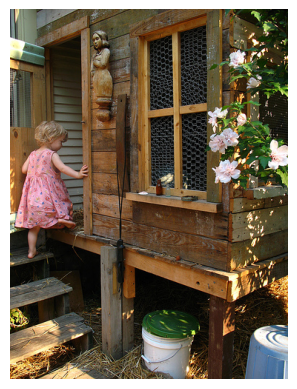

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

def test_on_random_image(img_name, model, features, mapping, tokenizer, max_length):
    # Display the image
    img_path = f"flickr8k/Images/{img_name}"
    image = Image.open(img_path)
    plt.imshow(image)
    plt.axis('off')

    # Get predictions and references
    feature = features[img_name]
    predict = predict_caption(model, feature, tokenizer, max_length)
    references = mapping[img_name.split('.')[0]]

    print(f"--- Predicted ---\n{predict}")
    print(f"--- Actual (Ground Truth) ---\n{references[0]}")
    plt.show()

# Example usage
test_on_random_image('1000268201_693b08cb0e.jpg', model, features, mapping, tokenizer, max_length)